In [31]:
import csv
import os
import subprocess
import tempfile
from pathlib import Path

TOOL = "actionlint"

# Always resolve paths from the CURRENT working directory of the notebook
TOOL_BIN = Path("../tools/actionlint/actionlint").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"  # real,user,sys

def parse_time_output(text: str):
    """
    GNU time may write extra lines like:
      'Command exited with non-zero status 127'
    We only parse the LAST line that looks like: float,float,float
    """
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()

    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

# Quick sanity checks (these help you catch the 127 root cause immediately)
if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

results = []
for wf in sorted(WORKFLOW_DIR.glob("*.yml")) + sorted(WORKFLOW_DIR.glob("*.yaml")):
    rc, t = run_timed([str(TOOL_BIN), str(wf)])
    if t is None:
        # still record something if you want, but usually this means tool didn't run properly
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    writer.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/actionlint_times.csv


In [32]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "frizbee"
TOOL_BIN = Path("../tools/frizbee/frizbee").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"  # real,user,sys

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

cmd_prefix = [str(TOOL_BIN), "actions", "-n"]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf)])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/frizbee_times.csv


In [33]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "pinny"
TOOL_BIN = Path("../tools/pinny/pinny").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

cmd_prefix = [str(TOOL_BIN), "actions", "pin", "--dry-run", "--file"]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf)])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/pinny_times.csv


In [34]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "scharf"
TOOL_BIN = Path("../tools/scharf/scharf").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

cmd_prefix = [str(TOOL_BIN), "audit"]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf)])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/scharf_times.csv


In [35]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "ggshield"
TOOL_BIN = Path("../tools/ggshield/ggshield").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

# Keep same semantics you used: secret scan path <file> --recursive
cmd_prefix = [str(TOOL_BIN), "secret", "scan", "--all-secrets", "path"]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf), "--recursive"])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/ggshield_times.csv


In [36]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "zizmor"
TOOL_BIN = Path("../tools/zizmor/zizmor").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

cmd_prefix = [str(TOOL_BIN)]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf)])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/zizmor_times.csv


In [37]:
import os
import csv
import tempfile
import subprocess
from pathlib import Path

TOOL = "poutine"
TOOL_BIN = Path("../tools/poutine/poutine").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

cmd_prefix = [str(TOOL_BIN), "analyze_local"]

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))
for wf in workflow_files:
    rc, t = run_timed(cmd_prefix + [str(wf)])
    if t is None:
        continue
    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/poutine_times.csv


In [38]:
import os
import csv
import shutil
import tempfile
import subprocess
from pathlib import Path

TOOL = "scorecard"
TOOL_BIN = Path("../tools/scorecard/scorecard").resolve()
WORKFLOW_DIR = Path("../.github/workflows").resolve()
TEMP_REPO_DIR = Path("scorecard_tmp_repo").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not TOOL_BIN.exists():
    raise FileNotFoundError(f"Tool binary not found: {TOOL_BIN}")
if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

(TEMP_REPO_DIR / ".github" / "workflows").mkdir(parents=True, exist_ok=True)
temp_wf_dir = TEMP_REPO_DIR / ".github" / "workflows"

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))

for wf in workflow_files:
    for f in temp_wf_dir.glob("*"):
        f.unlink()

    shutil.copy(wf, temp_wf_dir / wf.name)

    rc, t = run_timed([str(TOOL_BIN), f"--local={TEMP_REPO_DIR}", "--format=json"])
    if rc != 0 or t is None:
        continue

    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/scorecard_times.csv


In [39]:
import os
import csv
import shutil
import tempfile
import subprocess
from pathlib import Path

TOOL = "semgrep"
WORKFLOW_DIR = Path("../.github/workflows").resolve()
TEMP_DIR = Path("semgrep_temp").resolve()
OUT_DIR = Path("../results/execution_time") 
OUT_DIR.mkdir(parents=True, exist_ok=True)  
OUTPUT_CSV = OUT_DIR / f"{TOOL}_times.csv"

TIME_BIN = "/usr/bin/time"
TIME_FORMAT = "%e,%U,%S"

def parse_time_output(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    for ln in reversed(lines):
        parts = ln.split(",")
        if len(parts) == 3:
            try:
                return [float(p) for p in parts]
            except ValueError:
                continue
    return None

def run_timed(cmd):
    tmp = tempfile.NamedTemporaryFile(delete=False)
    tmp_path = tmp.name
    tmp.close()
    try:
        proc = subprocess.run(
            [TIME_BIN, "--quiet", "-f", TIME_FORMAT, "-o", tmp_path, "--"] + cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        raw = Path(tmp_path).read_text(encoding="utf-8", errors="replace")
        parsed = parse_time_output(raw)
        return proc.returncode, parsed
    finally:
        try:
            os.remove(tmp_path)
        except FileNotFoundError:
            pass

if not WORKFLOW_DIR.exists():
    raise FileNotFoundError(f"Workflow dir not found: {WORKFLOW_DIR}")

# Create temp repo structure once
(TEMP_DIR / ".github" / "workflows").mkdir(parents=True, exist_ok=True)
temp_wf_dir = TEMP_DIR / ".github" / "workflows"

results = []
workflow_files = sorted(list(WORKFLOW_DIR.glob("*.yml")) + list(WORKFLOW_DIR.glob("*.yaml")))

for wf in workflow_files:
    # clean previous file(s)
    for f in temp_wf_dir.glob("*"):
        f.unlink()

    shutil.copy(wf, temp_wf_dir / wf.name)

    rc, t = run_timed(["semgrep", "--config", "p/github-actions", "--quiet", str(TEMP_DIR)])
    if rc != 0 or t is None:
        continue

    real_s, user_s, sys_s = t
    results.append((wf.name, round(real_s, 4), round(user_s, 4), round(sys_s, 4), round(user_s + sys_s, 4)))

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["file", "real_seconds", "user_seconds", "sys_seconds", "cpu_seconds"])
    w.writerows(results)

print(f"[OK] Saved: {OUTPUT_CSV}")


[OK] Saved: ../results/execution_time/semgrep_times.csv


In [41]:
import pandas as pd
from pathlib import Path
import re

base = Path("../analyze/time_execution").resolve()
run_dirs = sorted([p for p in base.glob("execution_time*") if p.is_dir()])
print("Base:", base)
print("Run dirs:", [p.name for p in run_dirs])

rows = []
run_num_re = re.compile(r"execution_time(\d+)")

for d in run_dirs:
    m = run_num_re.search(d.name)
    run = int(m.group(1)) if m else d.name

    csvs = sorted(d.glob("*_times.csv"))  # matches actionlint_times.csv etc.
    print(d.name, "files:", len(csvs))

    for p in csvs:
        tool = p.stem.replace("_times", "")
        df = pd.read_csv(p)
        df["tool"] = tool
        df["run"] = run
        rows.append(df)

if not rows:
    raise ValueError(f"No *_times.csv found under {base}. Check folder contents.")

all_df = pd.concat(rows, ignore_index=True)

# Aggregate across the 3 runs per (tool, file)
agg = (all_df.groupby(["tool", "file"])
       .agg(
           real_median=("real_seconds", "median"),
           cpu_median=("cpu_seconds", "median"),
           real_min=("real_seconds", "min"),
           real_max=("real_seconds", "max"),
       )
       .reset_index())

agg["cpu_frac_median"] = agg["cpu_median"] / agg["real_median"]
agg["range_real"] = agg["real_max"] - agg["real_min"]

out_dir = base / "aggregated"
out_dir.mkdir(parents=True, exist_ok=True)

agg.to_csv(out_dir / "execution_time_aggregated.csv", index=False)

# Minimal per-tool summary (lightweight)
summary = (agg.groupby("tool")
           .agg(
               median_real=("real_median", "median"),
               p90_real=("real_median", lambda x: x.quantile(0.90)),
               median_cpu_frac=("cpu_frac_median", "median"),
           )
           .reset_index()
           .sort_values("median_real"))

summary.to_csv(out_dir / "performance_minimal_summary.csv", index=False)

print("Saved:")
print(out_dir / "execution_time_aggregated.csv")
print(out_dir / "performance_minimal_summary.csv")

Base: /home/huawei/github-actions-security/analyze/time_execution
Run dirs: ['execution_time1', 'execution_time2', 'execution_time3']
execution_time1 files: 9
execution_time2 files: 9
execution_time3 files: 9
Saved:
/home/huawei/github-actions-security/analyze/time_execution/aggregated/execution_time_aggregated.csv
/home/huawei/github-actions-security/analyze/time_execution/aggregated/performance_minimal_summary.csv


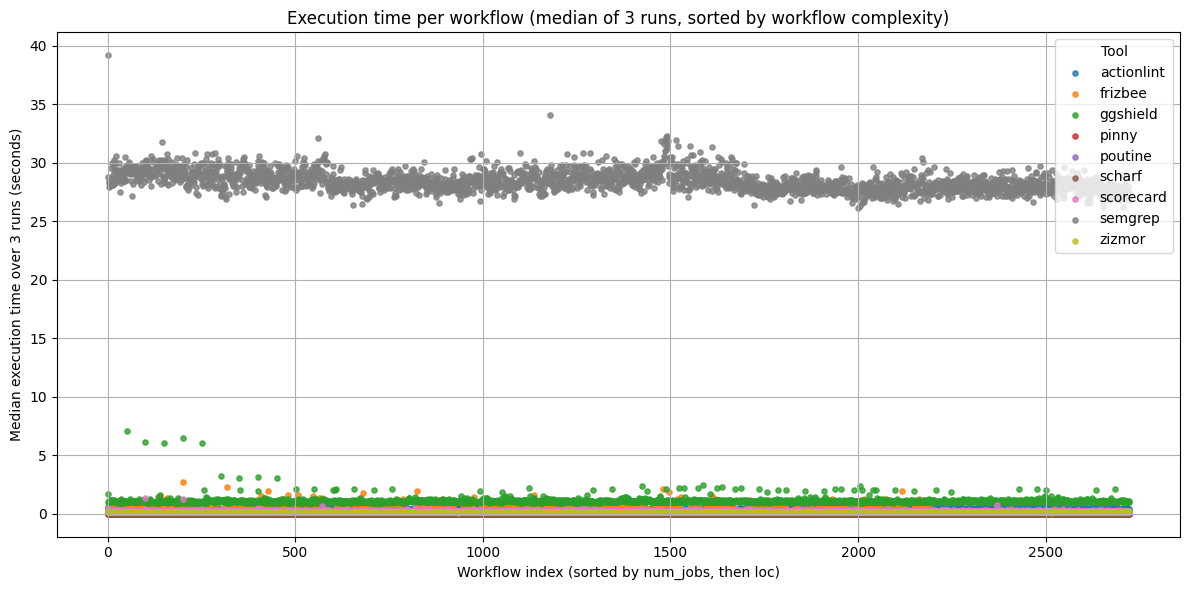

Unmatched workflows (no metadata match): 2722 / 2722


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Paths ---
meta_path = Path("../dataset/workflow_metadata.csv")
base_runs = Path("../analyze/time_execution")

run_dirs = [
    base_runs / "execution_time1",
    base_runs / "execution_time2",
    base_runs / "execution_time3",
]

# --- Load metadata ---
meta = pd.read_csv(meta_path)  # repo,workflow_file,loc,num_jobs,...
meta["k_workflow"] = meta["workflow_file"].astype(str)
meta["k_repo_path"] = meta["repo"].astype(str).str.rstrip("/") + "/" + meta["workflow_file"].astype(str).str.lstrip("/")
meta["k_basename"] = meta["workflow_file"].astype(str).str.split("/").str[-1]

key_map = pd.concat(
    [
        meta[["k_workflow", "loc", "num_jobs"]].rename(columns={"k_workflow": "file"}),
        meta[["k_repo_path", "loc", "num_jobs"]].rename(columns={"k_repo_path": "file"}),
        meta[["k_basename", "loc", "num_jobs"]].rename(columns={"k_basename": "file"}),
    ],
    ignore_index=True
).drop_duplicates(subset=["file"])

# --- Load 3 runs and stack into long format ---
rows = []
for d in run_dirs:
    if not d.exists():
        raise FileNotFoundError(f"Run directory not found: {d}")

    for p in sorted(d.glob("*_times.csv")):
        tool = p.stem.replace("_times", "")
        df = pd.read_csv(p)  # file, real_seconds, user_seconds, sys_seconds, cpu_seconds
        df["tool"] = tool
        rows.append(df[["file", "tool", "real_seconds"]])

if not rows:
    raise ValueError("No *_times.csv files found in the run folders.")

all_runs = pd.concat(rows, ignore_index=True)

# --- Median real time across runs per tool+file ---
med = (all_runs.groupby(["file", "tool"])["real_seconds"]
       .median()
       .reset_index()
       .rename(columns={"real_seconds": "real_median"}))

# --- Pivot to wide: columns = tools, rows = files ---
wide = med.pivot(index="file", columns="tool", values="real_median").reset_index()

tool_cols = [c for c in wide.columns if c != "file"]

# --- Merge with metadata ---
df = wide.merge(key_map, on="file", how="left")
df["num_jobs"] = pd.to_numeric(df["num_jobs"], errors="coerce")
df["loc"] = pd.to_numeric(df["loc"], errors="coerce")

# --- Sort workflows by num_jobs then loc ---
df = df.sort_values(by=["num_jobs", "loc"], ascending=[True, True], na_position="last").reset_index(drop=True)

# --- Plot: points only ---
plt.figure(figsize=(12, 6))
x = range(1, len(df) + 1)

for tool in tool_cols:
    y = pd.to_numeric(df[tool], errors="coerce")
    plt.scatter(x, y, label=tool, s=14, alpha=0.8)

plt.xlabel("Workflow index (sorted by num_jobs, then loc)")
plt.ylabel("Median execution time over 3 runs (seconds)")
plt.title("Execution time per workflow (median of 3 runs, sorted by workflow complexity)")
plt.legend(title="Tool", loc="upper right", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Unmatched workflows (no metadata match): {df['num_jobs'].isna().sum()} / {len(df)}")

In [1]:
import pandas as pd
from pathlib import Path
import re

base = Path("../analyze/time_execution").resolve()
run_dirs = sorted([p for p in base.glob("execution_time*") if p.is_dir()])

rows = []
run_num_re = re.compile(r"execution_time(\d+)")

for d in run_dirs:
    m = run_num_re.search(d.name)
    run = int(m.group(1)) if m else d.name
    for p in d.glob("*_times.csv"):
        tool = p.stem.replace("_times", "")
        df = pd.read_csv(p)
        df["tool"] = tool
        df["run"] = run
        rows.append(df)

all_df = pd.concat(rows, ignore_index=True)

# per tool+file median across 3 runs
per_file = (all_df.groupby(["tool","file"])
            .agg(real=("real_seconds","median"),
                 cpu=("cpu_seconds","median"),
                 user=("user_seconds","median"),
                 sys=("sys_seconds","median"))
            .reset_index())

per_file["overhead"] = per_file["real"] - per_file["cpu"]
per_file["cpu_frac"] = per_file["cpu"] / per_file["real"]
per_file["sys_frac"] = per_file["sys"] / per_file["cpu"]

summary = (per_file.groupby("tool")
           .agg(median_real=("real","median"),
                p90_real=("real", lambda x: x.quantile(0.90)),
                median_cpu=("cpu","median"),
                median_overhead=("overhead","median"),
                median_cpu_frac=("cpu_frac","median"),
                median_sys_frac=("sys_frac","median"))
           .reset_index()
           .sort_values("median_real"))

summary.to_csv(base / "aggregated" / "performance_cpu_breakdown.csv", index=False)
print(summary)

         tool  median_real  p90_real  median_cpu  median_overhead  \
3       pinny        0.000      0.00        0.00             0.00   
5      scharf        0.000      0.00        0.00             0.00   
8      zizmor        0.110      0.13        0.11             0.01   
1     frizbee        0.205      0.65        0.03             0.17   
4     poutine        0.220      0.25        0.39            -0.17   
6   scorecard        0.250      0.28        0.17             0.08   
0  actionlint        0.400      0.43        0.04             0.36   
2    ggshield        1.030      1.18        0.67             0.35   
7     semgrep       28.310     29.56        3.92            24.38   

   median_cpu_frac  median_sys_frac  
3              inf         0.500000  
5         0.000000              NaN  
8         0.923077         0.300000  
1         0.120000         0.333333  
4         1.761905         0.076923  
6         0.680000         0.352941  
0         0.100000         1.000000  
2    

In [2]:
import pandas as pd
from pathlib import Path
import re

base = Path("../analyze/time_execution").resolve()
run_dirs = sorted([p for p in base.glob("execution_time*") if p.is_dir()])

rows = []
run_num_re = re.compile(r"execution_time(\d+)")

for d in run_dirs:
    m = run_num_re.search(d.name)
    run = int(m.group(1)) if m else d.name

    for p in d.glob("*_times.csv"):
        tool = p.stem.replace("_times", "")
        df = pd.read_csv(p)  # file, real_seconds, user_seconds, sys_seconds, cpu_seconds
        df["tool"] = tool
        df["run"] = run
        rows.append(df[["tool", "file", "real_seconds"]])

if not rows:
    raise ValueError(f"No timing CSVs found under {base}")

all_df = pd.concat(rows, ignore_index=True)

# Median real time per (tool, file) across the 3 runs
per_file_med = (all_df.groupby(["tool", "file"])["real_seconds"]
                .median()
                .reset_index()
                .rename(columns={"real_seconds": "real_median"}))

# Max median time per tool (worst-case median across workflows)
max_median_by_tool = (per_file_med.groupby("tool")["real_median"]
                      .max()
                      .reset_index()
                      .rename(columns={"real_median": "max_median_real"}))

max_median_by_tool = max_median_by_tool.sort_values("max_median_real", ascending=False)

out_path = base / "aggregated" / "max_median_real_by_tool.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
max_median_by_tool.to_csv(out_path, index=False)

print("Saved:", out_path)
print(max_median_by_tool)

Saved: /home/huawei/github-actions-security/analyze/time_execution/aggregated/max_median_real_by_tool.csv
         tool  max_median_real
7     semgrep            39.19
2    ggshield             7.10
1     frizbee             2.71
6   scorecard             1.31
0  actionlint             0.53
4     poutine             0.39
8      zizmor             0.26
3       pinny             0.06
5      scharf             0.03
